# VADER vs RoBERTa — Sentiment Comparison
Upload your CSV and set the column names below. That's it.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score
from google.colab import files

uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)
print(df.head())
print('\nColumns:', df.columns.tolist())

Saving sentiment_results.csv to sentiment_results.csv
                                        cleaned_text  Vader  RoBERTa
0                               not_want news google      0       -1
1  trump dumbest president american history terri...     -1       -1
2  fareed know full well reason many objected jcp...     -1       -1
3  china 's xinjiang genocide million visited xin...     -1       -1
4                           jet pilot need precision      0        0

Columns: ['cleaned_text', 'Vader', 'RoBERTa']


In [9]:
# ── CONFIG ── adjust these to match your actual column names
VADER_COL   = 'Vader'
ROBERTA_COL = 'RoBERTa'
TEXT_COL    = 'cleaned_text'

LABELS = [-1, 0, 1]

In [8]:
print(df['Vader'].unique())
print(df['RoBERTa'].unique())

[ 0 -1  1]
[-1  0  1]


## 1 · Label Distribution

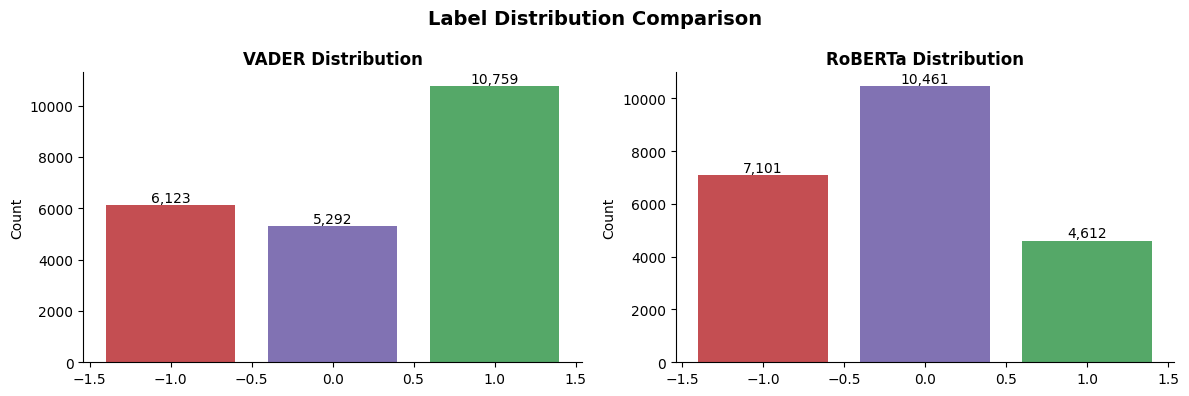

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, title in zip(axes, [VADER_COL, ROBERTA_COL], ['VADER', 'RoBERTa']):
    counts = df[col].value_counts().reindex(LABELS, fill_value=0)
    bars = ax.bar(counts.index, counts.values, color=['#C44E52', '#8172B3', '#55A868'])
    ax.set_title(f'{title} Distribution', fontweight='bold')
    ax.set_ylabel('Count')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{bar.get_height():,}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Label Distribution Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 2 · Agreement Rate & Cohen's Kappa

In [11]:
agree = (df[VADER_COL] == df[ROBERTA_COL]).sum()
total = len(df)
agreement_rate = agree / total * 100
kappa = cohen_kappa_score(df[VADER_COL], df[ROBERTA_COL])

print(f'Total rows      : {total:,}')
print(f'Agreements      : {agree:,}  ({agreement_rate:.1f}%)')
print(f'Disagreements   : {total - agree:,}  ({100 - agreement_rate:.1f}%)')
print(f"Cohen's Kappa   : {kappa:.3f}  ", end='')
if   kappa >= 0.8:  print('(Almost perfect)')
elif kappa >= 0.6:  print('(Substantial)')
elif kappa >= 0.4:  print('(Moderate)')
elif kappa >= 0.2:  print('(Fair)')
else:               print('(Poor)')

Total rows      : 22,174
Agreements      : 12,557  (56.6%)
Disagreements   : 9,617  (43.4%)
Cohen's Kappa   : 0.379  (Fair)


## 3 · Confusion Matrix (VADER rows → RoBERTa columns)

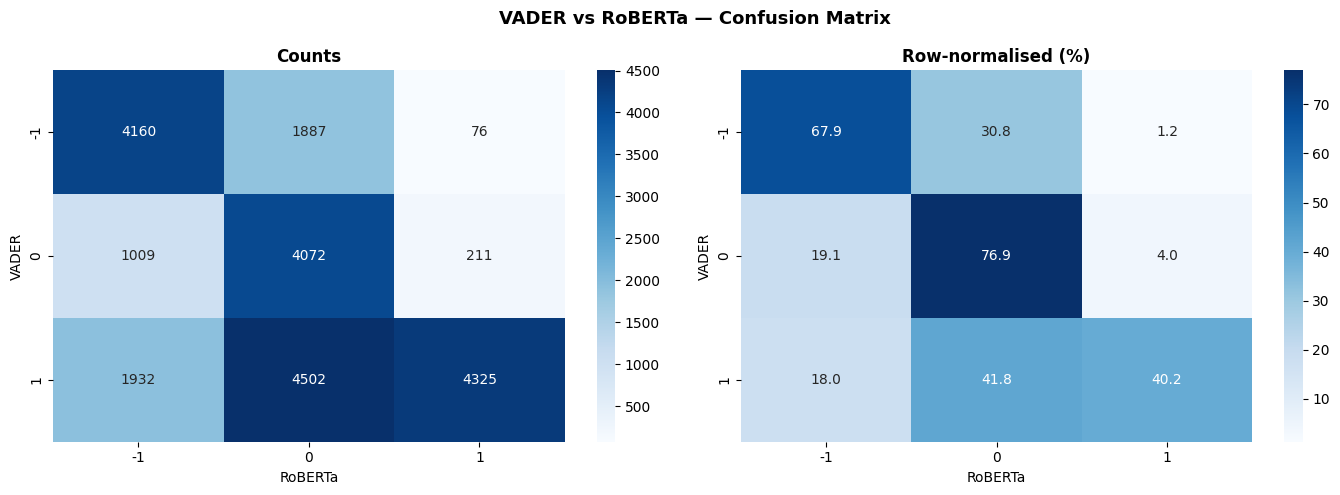

In [12]:
cm = confusion_matrix(df[VADER_COL], df[ROBERTA_COL], labels=LABELS)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABELS, yticklabels=LABELS, ax=axes[0])
axes[0].set_title('Counts', fontweight='bold')
axes[0].set_xlabel('RoBERTa')
axes[0].set_ylabel('VADER')

# Row-normalised (% of each VADER label)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_norm, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=LABELS, yticklabels=LABELS, ax=axes[1])
axes[1].set_title('Row-normalised (%)', fontweight='bold')
axes[1].set_xlabel('RoBERTa')
axes[1].set_ylabel('VADER')

plt.suptitle('VADER vs RoBERTa — Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4 · Where They Disagree

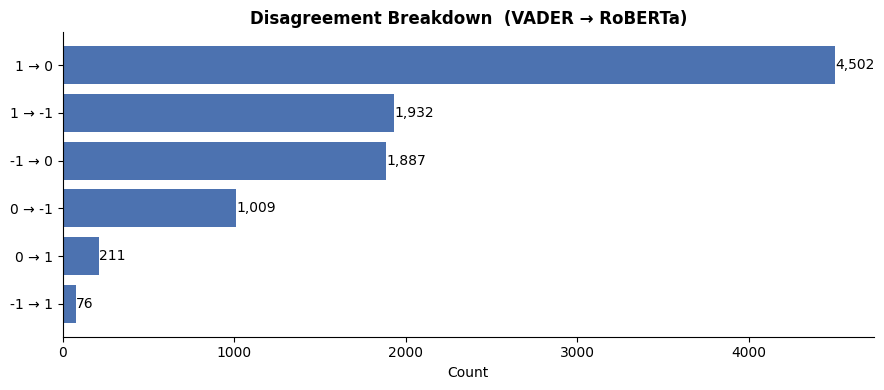

In [14]:
disagree = df[df[VADER_COL] != df[ROBERTA_COL]].copy()
disagree['pair'] = disagree[VADER_COL].astype(str) + ' → ' + disagree[ROBERTA_COL].astype(str)

pair_counts = disagree['pair'].value_counts()

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(pair_counts.index[::-1], pair_counts.values[::-1], color='#4C72B0')
ax.set_title('Disagreement Breakdown  (VADER → RoBERTa)', fontweight='bold')
ax.set_xlabel('Count')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for bar in bars:
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():,}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

## 5 · Sample Disagreements (spot-check)

In [15]:
N = 5  # samples per disagreement pair

for pair in pair_counts.index:
    v_label, r_label = pair.split(' → ')
    subset = disagree[
        (disagree[VADER_COL] == v_label) &
        (disagree[ROBERTA_COL] == r_label)
    ]
    print(f'\n── VADER={v_label.upper()}  →  RoBERTa={r_label.upper()}  ({len(subset):,} cases) ──')
    sample_col = TEXT_COL if TEXT_COL in df.columns else df.columns[0]
    for _, row in subset.head(N).iterrows():
        print(f'  • {str(row[sample_col])[:120]}')


── VADER=1  →  RoBERTa=0  (0 cases) ──

── VADER=1  →  RoBERTa=-1  (0 cases) ──

── VADER=-1  →  RoBERTa=0  (0 cases) ──

── VADER=0  →  RoBERTa=-1  (0 cases) ──

── VADER=0  →  RoBERTa=1  (0 cases) ──

── VADER=-1  →  RoBERTa=1  (0 cases) ──


## 6 · Per-class Agreement Rates

In [16]:
print(f'{"Label":<12} {"VADER N":>8} {"RoBERTa N":>10} {"Both agree":>12} {"Agree %":>9}')
print('-' * 55)
for label in LABELS:
    v_set = set(df[df[VADER_COL] == label].index)
    r_set = set(df[df[ROBERTA_COL] == label].index)
    both  = df[(df[VADER_COL] == label) & (df[ROBERTA_COL] == label)]
    denom = len(v_set | r_set)
    pct   = len(both) / denom * 100 if denom else 0
    print(f'{label:<12} {len(v_set):>8,} {len(r_set):>10,} {len(both):>12,} {pct:>8.1f}%')

Label         VADER N  RoBERTa N   Both agree   Agree %
-------------------------------------------------------
-1              6,123      7,101        4,160     45.9%
0               5,292     10,461        4,072     34.9%
1              10,759      4,612        4,325     39.2%
